<a href="https://colab.research.google.com/github/edgardlt03/ICO-Trabajos/blob/main/Redes_Convolucionales_con_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ASL Recognition with CNNs

This notebook implements a Convolutional Neural Network (CNN) for recognizing American Sign Language (ASL) gestures. We will compare the performance of a Fully Connected Neural Network (FCNN) with that of a CNN on the ASL dataset.

For more information on the ASL alphabet, you can refer to this site: https://www.asl.gs/

In [4]:
import random
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

In [6]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

CLASSES     = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
IMG_CHANNELS = 3
IMG_HEIGHT   = 32
IMG_WIDTH    = 32
NUM_CLASSES  = 10

### Load data

The data for the ASL dataset is stored in CSV files. It is already split into training, validation, and test sets. Each row in the CSV files contains pixel values for a 28x28 image (flattened into a single row) and a label indicating the ASL gesture.

The labels are integers from 0 to 23, corresponding to the letters A-Z (J and Z are excluded because they require movement).

The images are grayscale, so each pixel value ranges from 0 to 255.

In [7]:
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples:  {len(test_dataset)}")

100%|██████████| 170M/170M [00:13<00:00, 12.3MB/s]


Train samples: 50000
Test samples:  10000


## Preparing dataset

Let's start by creating the custom Dataset class for our ASL data. This class will take a DataFrame as input and will return the image and label for each sample. We will also normalize the pixel values to be between 0 and 1. The images will be reshaped as a 28x28 tensor with a single channel (grayscale).

In [8]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2)

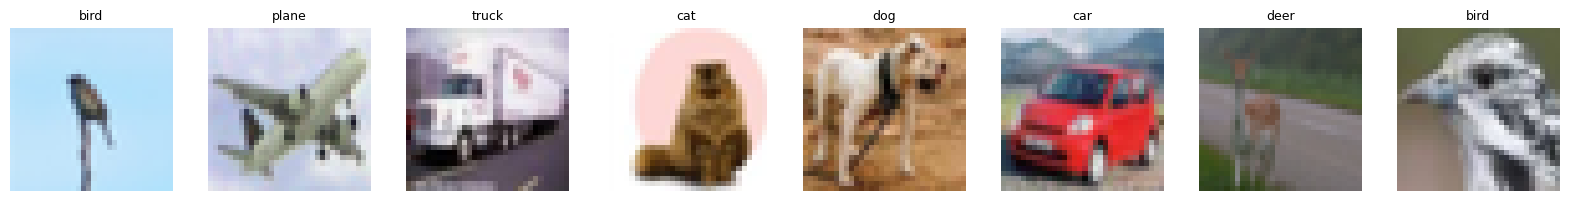

In [13]:
def show_samples(dataset, n=8):
    indices = random.sample(range(len(dataset)), n)
    fig, axes = plt.subplots(1, n, figsize=(2*n, 2))
    for ax, idx in zip(axes, indices):
        img, label = dataset[idx]
        mean = torch.tensor(CIFAR10_MEAN).view(3,1,1)
        std  = torch.tensor(CIFAR10_STD).view(3,1,1)
        img  = (img * std + mean).permute(1, 2, 0).clamp(0, 1).numpy()
        ax.imshow(img)
        ax.set_title(CLASSES[label], fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(train_dataset)

## Training functions

Now we can define our training functions. Since we will use accuracy to evaluate our model, we will create a function to calculate accuracy as well.

In [12]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

Our train function performs the full training loop. For each epoch, it computes the training loss and accuracy, and then evaluates the model on the validation set. It returns the history of training and validation losses and accuracies for plotting later.

In [13]:
def train(_model, _train_loader, _test_loader, _criterion, _optimizer, _num_epochs):
    res = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    iterator = tqdm(range(_num_epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc  = 0.0
        for X_batch, y_batch in _train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc  += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        test_loss = 0.0
        test_acc  = 0.0
        with torch.no_grad():
            for X_batch, y_batch in _test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs   = _model(X_batch)
                test_loss += _criterion(outputs, y_batch).item() * X_batch.size(0)
                test_acc  += get_batch_accuracy(outputs, y_batch, len(_test_loader.dataset))

        epoch_test_loss = test_loss / len(_test_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}", train_acc=f"{train_acc:.4f}",
            test_loss=f"{epoch_test_loss:.4f}",  test_acc=f"{test_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['test_loss'].append(epoch_test_loss)
        res['test_acc'].append(test_acc)

    return res

This test function will evaluate the model on the test set after training is complete. It will calculate the average loss and accuracy across the entire test set.

In [14]:
def evaluate(_model, _test_loader, _criterion):
    _model.eval()
    test_loss = 0.0
    test_acc  = 0.0
    with torch.no_grad():
        for X_batch, y_batch in _test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            output    = _model(X_batch)
            test_loss += _criterion(output, y_batch).item() * X_batch.size(0)
            test_acc  += get_batch_accuracy(output, y_batch, len(_test_loader.dataset))
    return test_loss / len(_test_loader.dataset), test_acc

### CNN model

Now let's implement a simple CNN architecture. We will use three convolutional layers followed by max pooling, and then a couple of fully connected layers before the output layer.

In [24]:
model_a = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 32, kernel_size=3, padding=1),  # 32 x 32 x 32
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),                               # 32 x 16 x 16

    nn.Conv2d(32, 64, kernel_size=3, padding=1),             # 64 x 16 x 16
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),                               # 64 x 8 x 8

    nn.Flatten(),
    nn.Linear(64 * 8 * 8, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, NUM_CLASSES)
).to(device)

In [18]:
model_b = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 32, kernel_size=3, padding=1),  # 32 x 32 x 32
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),                               # 32 x 16 x 16

    nn.Conv2d(32, 64, kernel_size=3, padding=1),             # 64 x 16 x 16
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.MaxPool2d(2, stride=2),                               # 64 x 8 x 8

    nn.Conv2d(64, 128, kernel_size=3, padding=1),            # 128 x 8 x 8
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),                               # 128 x 4 x 4

    nn.Flatten(),
    nn.Linear(128 * 4 * 4, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, NUM_CLASSES)
).to(device)

In [19]:
model_c = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 64, kernel_size=3, padding=1),  # 64 x 32 x 32
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),                               # 64 x 16 x 16

    nn.Conv2d(64, 128, kernel_size=3, padding=1),            # 128 x 16 x 16
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.MaxPool2d(2, stride=2),                               # 128 x 8 x 8

    nn.Conv2d(128, 256, kernel_size=3, padding=1),           # 256 x 8 x 8
    nn.BatchNorm2d(256),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),                               # 256 x 4 x 4

    nn.Flatten(),
    nn.Linear(256 * 4 * 4, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, NUM_CLASSES)
).to(device)

## Training the models

In [20]:
epochs        = 20
learning_rate = 1e-3
loss_function = nn.CrossEntropyLoss()

In [25]:
optimizer_a = Adam(model_a.parameters(), lr=learning_rate)
res_a = train(model_a, train_loader, test_loader, loss_function, optimizer_a, epochs)

Training: 100%|██████████| 20/20 [05:17<00:00, 15.88s/epoch, test_acc=0.7322, test_loss=1.3295, train_acc=0.9416, train_loss=0.1598]


In [26]:
optimizer_b = Adam(model_b.parameters(), lr=learning_rate)
res_b = train(model_b, train_loader, test_loader, loss_function, optimizer_b, epochs)

Training: 100%|██████████| 20/20 [05:22<00:00, 16.11s/epoch, test_acc=0.7739, test_loss=1.0139, train_acc=0.9478, train_loss=0.1503]


In [27]:
optimizer_c = Adam(model_c.parameters(), lr=learning_rate)
res_c = train(model_c, train_loader, test_loader, loss_function, optimizer_c, epochs)

Training: 100%|██████████| 20/20 [05:29<00:00, 16.47s/epoch, test_acc=0.8236, test_loss=0.6797, train_acc=0.9497, train_loss=0.1425]


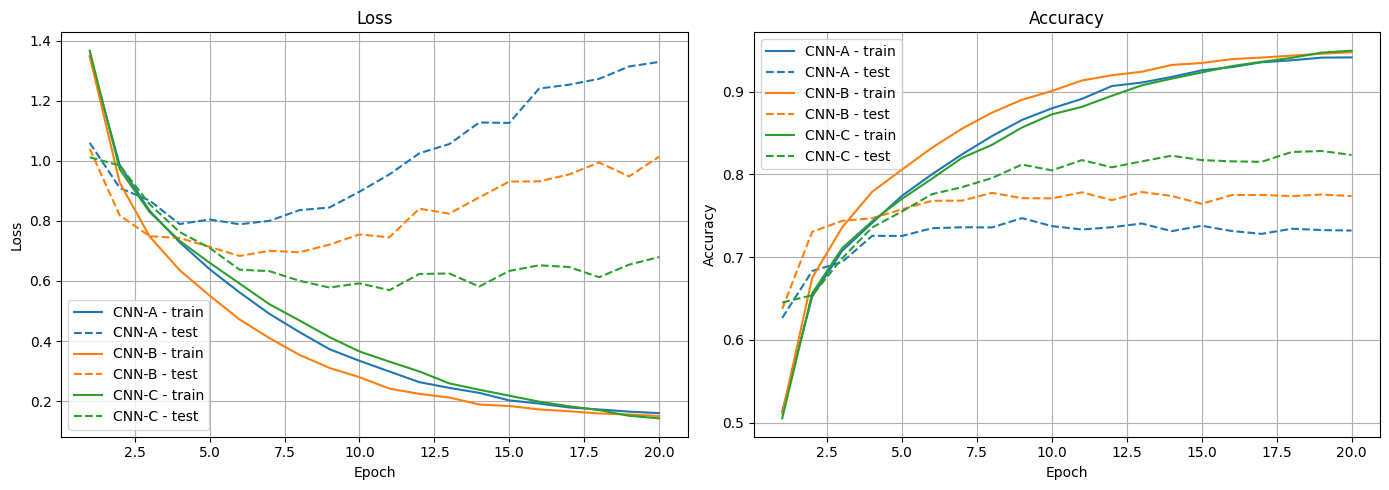

In [28]:
def plot_learning_curves(results_dict):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['tab:blue', 'tab:orange', 'tab:green']

    for (name, res), color in zip(results_dict.items(), colors):
        ep = range(1, len(res['train_loss']) + 1)
        axes[0].plot(ep, res['train_loss'], '-',  color=color, label=f"{name} - train")
        axes[0].plot(ep, res['test_loss'],  '--', color=color, label=f"{name} - test")
        axes[1].plot(ep, res['train_acc'],  '-',  color=color, label=f"{name} - train")
        axes[1].plot(ep, res['test_acc'],   '--', color=color, label=f"{name} - test")

    for ax, title in zip(axes, ['Loss', 'Accuracy']):
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(title)
        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    plt.show()

plot_learning_curves({'CNN-A': res_a, 'CNN-B': res_b, 'CNN-C': res_c})

In [29]:
loss_a, acc_a = evaluate(model_a, test_loader, loss_function)
loss_b, acc_b = evaluate(model_b, test_loader, loss_function)
loss_c, acc_c = evaluate(model_c, test_loader, loss_function)

print(f"CNN-A | Test Loss: {loss_a:.4f} | Test Accuracy: {acc_a:.4f}")
print(f"CNN-B | Test Loss: {loss_b:.4f} | Test Accuracy: {acc_b:.4f}")
print(f"CNN-C | Test Loss: {loss_c:.4f} | Test Accuracy: {acc_c:.4f}")

scores    = {'CNN-A': acc_a, 'CNN-B': acc_b, 'CNN-C': acc_c}
best_name = max(scores, key=scores.get)
print(f"\nBest model: {best_name} ({scores[best_name]:.4f})")

CNN-A | Test Loss: 1.3295 | Test Accuracy: 0.7322
CNN-B | Test Loss: 1.0139 | Test Accuracy: 0.7739
CNN-C | Test Loss: 0.6797 | Test Accuracy: 0.8236

Best model: CNN-C (0.8236)


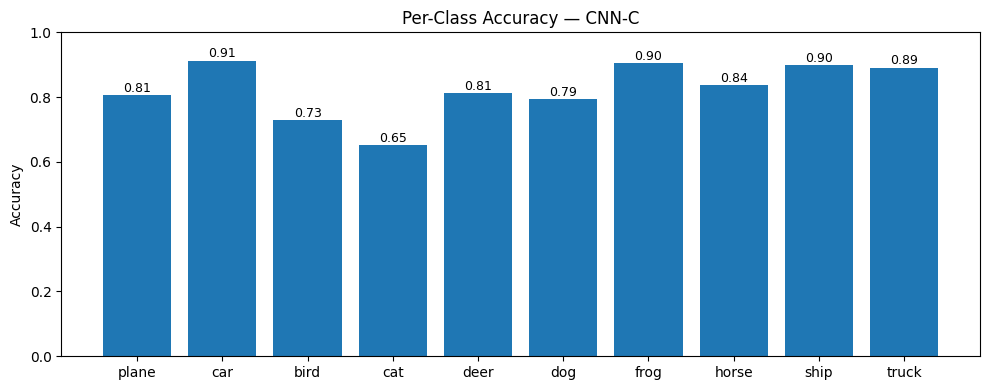

In [30]:

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds = best_model(X_batch).argmax(dim=1)
        for c in range(NUM_CLASSES):
            mask = y_batch == c
            correct_per_class[c] += (preds[mask] == c).sum().item()
            total_per_class[c]   += mask.sum().item()

per_class_acc = correct_per_class / total_per_class

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(CLASSES, per_class_acc.numpy())
ax.set_ylabel('Accuracy')
ax.set_title(f'Per-Class Accuracy — {best_name}')
ax.set_ylim(0, 1)
for i, v in enumerate(per_class_acc):
    ax.text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## Reflection section

### Final conclusions and remarks

en esta actividad entendi las distintas arquitecturas de red neuronal afectan directamente que tan bien aprende un modelo paraa clasificar imagenes no todas las redes son iguales una red mas pequena aprende mas rapido pero es mala en precisionn y que una mas completa tarda mas pero logra mejores resultados


Tambien vi  que agregar Batch ayuda a que el entrenamiento sea mas estable osea que no solo aprende de memoria los datos de entrenamiento sino que tambien con  imagenes que nunca habia visto


y que cada decision de arquitectura tiene un impacto grande en los resultados